# Generative Adversarial Nets — Math Formulas Explained with Python

This notebook walks through every key equation in Goodfellow et al. (2014),
with executable Python code alongside the LaTeX.

**Paper:** https://proceedings.neurips.cc/paper_files/paper/2014/file/f033ed80deb0234979a61f95710dbe25-Paper.pdf

## 0. Preamble

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from scipy.integrate import quad
from scipy.special import logit, expit  # expit = sigmoid

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 12})

---
## 1. The Minimax Value Function — Equation (1)

$$
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)} [\log D(x)] + \mathbb{E}_{z \sim p_z(z)} [\log(1 - D(G(z)))]
$$

**Meaning:** D wants to maximize V (correctly classify real vs. fake). G wants to minimize V (fool D).
The two expectations are approximated with minibatch averages in practice.

 ### 1.1 Syntax Breakdown — Token by Token

**min_G max_D** — The minimax game:
- `min` → "make this as small as possible"
- `max` → "make this as big as possible"
- `_G`, `_D` → who is doing it (Generator vs Discriminator)

**V(D, G)** — Just a name for the overall score. Like naming a variable `score = ...`

**𝔼** — Expected value = **average**. Delete 𝔼 mentally, replace with "average of..."

**Subscript `{x ~ p_data(x)}`**:

| Symbol | Meaning | In code |
|--------|---------|--------|
| `{ }` | "averaging over..." | The loop variable |
| `x` | A single real image | `x = ...` |
| `~` | "drawn from" / "sampled from" | `random.choice(...)` |
| `p_data(x)` | The collection of all real images | `real_images_dataset` |

**Subscript `{z ~ p_z(z)}`**:

| Symbol | Meaning | In code |
|--------|---------|--------|
| `z` | Random noise vector (e.g. 100 numbers) | `z = random.normal(0, 1, 100)` |
| `p_z(z)` | Noise distribution (usually standard normal) | bell curve, mean 0, std 1 |

**First term `[log D(x)]`**: D looks at real image x, returns 0-1. `log(1)` → 0 (no penalty), `log(0)` → -∞ (huge penalty).

**Second term `[log(1 - D(G(z)))]`**: G makes a fake image from noise, D judges it.
- `D(G(z))` → if 0 (correctly spotted fake): `log(1)` = 0 (D wins)
- `D(G(z))` → if 1 (fooled into thinking real): `log(0)` = -∞ (G wins)

### 1.2 The Whole Thing as Pseudocode

```python
def gan_score(D, G):
    # First term: how well D spots real images
    real_scores = []
    for x in real_images_dataset:
        real_scores.append(log(D(x)))
    real_term = mean(real_scores)

    # Second term: how well D spots fakes
    fake_scores = []
    for z in noise_samples:
        fake = G(z)
        fake_scores.append(log(1 - D(fake)))
    fake_term = mean(fake_scores)

    return real_term + fake_term

# D wants this number HIGH  (good at detecting)
# G wants this number LOW   (good at fooling)
```

**The two trickiest bits:**
1. `x ~ p_data(x)` → just "randomly grab an image from the training set"
2. The subscript under 𝔼 → answers "average over WHAT?" — everything under it tells you what's random and where it comes from

V(D_naive, G) = -1.3863
V(D_better, G)  = -1.0072


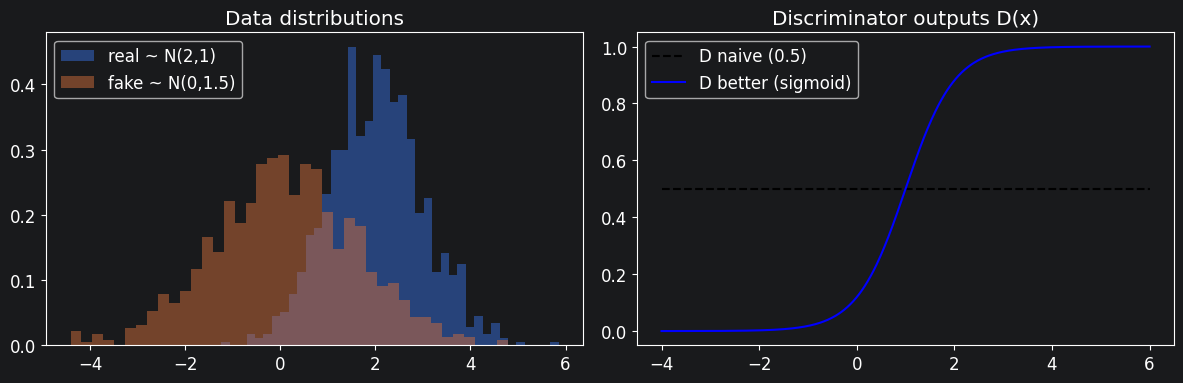

In [3]:
def value_function(D, real_x, fake_x):
    """Compute V(D,G) from Equation (1) as a minibatch estimate.
    
    Args:
        D: a function x -> probability that x is real (in [0,1])
        real_x: array of real samples (batch)
        fake_x: array of fake samples from G(z)
    Returns:
        scalar estimate of V(D,G)
    """
    real_term = np.mean(np.log(D(real_x) + 1e-12))
    fake_term = np.mean(np.log(1 - D(fake_x) + 1e-12))
    return real_term + fake_term

# ---- Demo: compute V for a toy D and G ----
real_data = np.random.randn(1000) * 1.0 + 2.0       # p_data: N(2, 1)
fake_data = np.random.randn(1000) * 1.5 + 0.0        # p_g:    N(0, 1.5)

# A naive D that guesses 0.5 everywhere (useless)
D_naive = lambda x: 0.5 * np.ones_like(x)
print(f"V(D_naive, G) = {value_function(D_naive, real_data, fake_data):.4f}")

# A better D: sigmoid of a simple linear boundary
D_better = lambda x: expit((x - 1.0) * 2.0)  # steep sigmoid crossing at 1.0
print(f"V(D_better, G)  = {value_function(D_better, real_data, fake_data):.4f}")

# ---- Visualise ----
x_grid = np.linspace(-4, 6, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(real_data, bins=40, alpha=0.5, density=True, label='real ~ N(2,1)')
ax1.hist(fake_data, bins=40, alpha=0.5, density=True, label='fake ~ N(0,1.5)')
ax1.legend(); ax1.set_title('Data distributions')
ax2.plot(x_grid, D_naive(x_grid), 'k--', label='D naive (0.5)')
ax2.plot(x_grid, D_better(x_grid), 'b-', label='D better (sigmoid)')
ax2.set_title('Discriminator outputs D(x)'); ax2.legend()
plt.tight_layout(); plt.show()

---
## 2. The Optimal Discriminator — Equation (2)

$$
D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
$$

**Derivation:** For a fixed G, V(G,D) = \int [p_data log D + p_g log(1-D)] dx.
The integrand `a*log(y) + b*log(1-y)` is maximised at `y = a/(a+b)` — set derivative to zero.

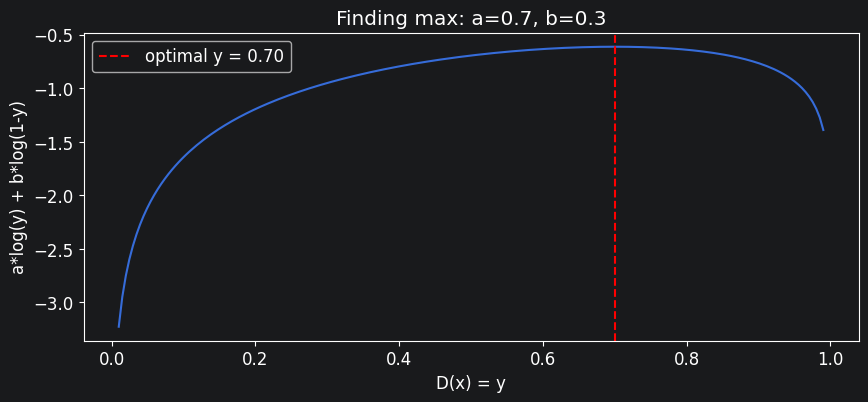

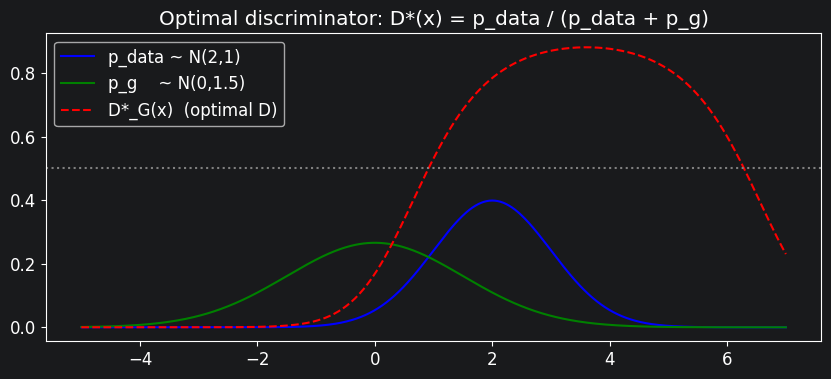

V(D_opt,  G) = -0.8891
V(D_better,G) = -0.9841  (sigmoid, suboptimal)


In [4]:
# ---- Show that a*log(y) + b*log(1-y) peaks at y = a/(a+b) ----
a, b = 0.7, 0.3          # p_data(x)=0.7, p_g(x)=0.3 at some x
y_opt = a / (a + b)       # = 0.7

y_vals = np.linspace(0.01, 0.99, 200)
f_vals = a * np.log(y_vals) + b * np.log(1 - y_vals)

plt.plot(y_vals, f_vals)
plt.axvline(y_opt, color='r', linestyle='--', label=f'optimal y = {y_opt:.2f}')
plt.xlabel('D(x) = y'); plt.ylabel('a*log(y) + b*log(1-y)')
plt.title(f'Finding max: a={a}, b={b}'); plt.legend(); plt.show()

# ---- Compute optimal D for two known Gaussians ----
p_data = lambda x: norm.pdf(x, loc=2.0, scale=1.0)       # N(2,1)
p_g    = lambda x: norm.pdf(x, loc=0.0, scale=1.5)       # N(0,1.5)

D_opt = lambda x: p_data(x) / (p_data(x) + p_g(x) + 1e-12)

x_grid = np.linspace(-5, 7, 500)
plt.plot(x_grid, p_data(x_grid), 'b-', label='p_data ~ N(2,1)')
plt.plot(x_grid, p_g(x_grid),    'g-', label='p_g    ~ N(0,1.5)')
plt.plot(x_grid, D_opt(x_grid),  'r--', label='D*_G(x)  (optimal D)')
plt.axhline(0.5, color='gray', linestyle=':')
plt.legend(); plt.title('Optimal discriminator: D*(x) = p_data / (p_data + p_g)')
plt.show()

# ---- Verify: V(D_opt, G) should be the max over all D for this G ----
real = np.random.randn(5000) * 1.0 + 2.0
fake = np.random.randn(5000) * 1.5 + 0.0
print(f"V(D_opt,  G) = {value_function(D_opt, real, fake):.4f}")
print(f"V(D_better,G) = {value_function(D_better, real, fake):.4f}  (sigmoid, suboptimal)")

---
## 3. Integral Form — Equation (3)

$$
V(G, D) = \int_x p_{\text{data}}(x) \log(D(x)) \,dx + \int_z p_z(z) \log(1 - D(G(z))) \,dz
$$

$$
= \int_x \Big[ p_{\text{data}}(x) \log(D(x)) + p_g(x) \log(1 - D(x)) \Big] dx
$$

The second line uses the **Law of the Unconscious Statistician (LOTUS):**
E_{z~p_z}[f(G(z))] = E_{x~p_g}[f(x)], i.e., expectations over z can be rewritten over x with density p_g.

In [5]:
# ---- Verify LOTUS numerically: E_z[log(1-D(G(z)))] == E_x~p_g[log(1-D(x))] ----
def G(z):
    """Simple generator: shift + scale noise."""
    return z * 1.5 + 0.0

z_samples = np.random.randn(100_000)
fake_x = G(z_samples)

# Both ways of computing the expectation:
via_z = np.mean(np.log(1 - D_better(G(z_samples)) + 1e-12))
via_x = np.mean(np.log(1 - D_better(fake_x) + 1e-12))
print(f"E_z[log(1-D(G(z)))] = {via_z:.6f}")
print(f"E_x~p_g[log(1-D(x))]  = {via_x:.6f}")
print(f"Difference: {abs(via_z - via_x):.2e}")

# ---- Numerical integration to compute V ----
def v_integral(p_data_fn, p_g_fn, D_fn, x_min=-10, x_max=10):
    """Compute V(G,D) via numerical integration (Eq. 3)."""
    integrand = lambda x: (p_data_fn(x) * np.log(D_fn(x) + 1e-12) +
                           p_g_fn(x)    * np.log(1 - D_fn(x) + 1e-12))
    val, _ = quad(integrand, x_min, x_max, limit=200)
    return val

v_int = v_integral(p_data, p_g, D_opt)
print(f"\nV(G,D*) via integration = {v_int:.4f}")
print(f"V(G,D*) via sampling   = {value_function(D_opt, real, fake):.4f}")

E_z[log(1-D(G(z)))] = -0.620500
E_x~p_g[log(1-D(x))]  = -0.620500
Difference: 0.00e+00

V(G,D*) via integration = -0.8799
V(G,D*) via sampling   = -0.8891


---
## 4. Generator's Criterion — Equation (4)

$$
C(G) = \max_D V(G, D) = \mathbb{E}_{x \sim p_{\text{data}}} [\log D^*_G(x)] + \mathbb{E}_{x \sim p_g} [\log(1 - D^*_G(x))]
$$

**Meaning:** C(G) is the best possible V when D is optimal. If p_g = p_data, then D*(x) = 1/2 everywhere and C(G) = log(1/2) + log(1/2) = -log 4 ~ -1.386.

In [6]:
print(f"Theoretical minimum C* = -log(4) = {-np.log(4):.4f}\n")

# ---- C(G) for various generators at different distances from p_data ----
mu_list = np.linspace(0.0, 4.0, 9)   # sweep generator mean toward data mean (2.0)

for mu in mu_list:
    p_g_mu = lambda x: norm.pdf(x, loc=mu, scale=1.5)
    D_opt_mu = lambda x: p_data(x) / (p_data(x) + p_g_mu(x) + 1e-12)
    
    # Sample-based estimate
    real_s = np.random.randn(10_000) * 1.0 + 2.0
    fake_s = np.random.randn(10_000) * 1.5 + mu
    c_val = np.mean(np.log(D_opt_mu(real_s) + 1e-12)) +             np.mean(np.log(1 - D_opt_mu(fake_s) + 1e-12))
    print(f"G ~ N({mu:.1f}, 1.5^2)   C(G) = {c_val:.4f}   (gap to -log4: {c_val + np.log(4):.4f})")

# As mu approaches 2.0, C(G) approaches -log(4)

Theoretical minimum C* = -log(4) = -1.3863

G ~ N(0.0, 1.5^2)   C(G) = -0.8818   (gap to -log4: 0.5045)
G ~ N(0.5, 1.5^2)   C(G) = -1.0513   (gap to -log4: 0.3349)
G ~ N(1.0, 1.5^2)   C(G) = -1.1875   (gap to -log4: 0.1987)
G ~ N(1.5, 1.5^2)   C(G) = -1.2739   (gap to -log4: 0.1124)
G ~ N(2.0, 1.5^2)   C(G) = -1.3125   (gap to -log4: 0.0738)
G ~ N(2.5, 1.5^2)   C(G) = -1.2777   (gap to -log4: 0.1086)
G ~ N(3.0, 1.5^2)   C(G) = -1.1865   (gap to -log4: 0.1998)
G ~ N(3.5, 1.5^2)   C(G) = -1.0546   (gap to -log4: 0.3316)
G ~ N(4.0, 1.5^2)   C(G) = -0.8944   (gap to -log4: 0.4918)


---
## 5. KL Divergence & Jensen-Shannon — Equations (5) & (6)

$$
C(G) = -\log 4 + \text{KL}\left(p_{\text{data}} \;\Big\Vert\; \frac{p_{\text{data}} + p_g}{2}\right) + \text{KL}\left(p_g \;\Big\Vert\; \frac{p_{\text{data}} + p_g}{2}\right)
$$

$$
C(G) = -\log 4 + 2 \cdot \text{JSD}(p_{\text{data}} \;\Vert\; p_g)
$$

$$
\text{JSD}(P \Vert Q) = \frac{1}{2}\text{KL}(P \Vert M) + \frac{1}{2}\text{KL}(Q \Vert M), \quad M = \frac{P+Q}{2}
$$

**The punchline:** Minimising C(G) is the same as minimising JSD(p_data || p_g).
GAN training is gradient descent on the Jensen-Shannon divergence!

C(G)  via sampling  = -0.8885
-log4 + 2*JSD est   = 0.4696
JSD estimate        = 0.9280


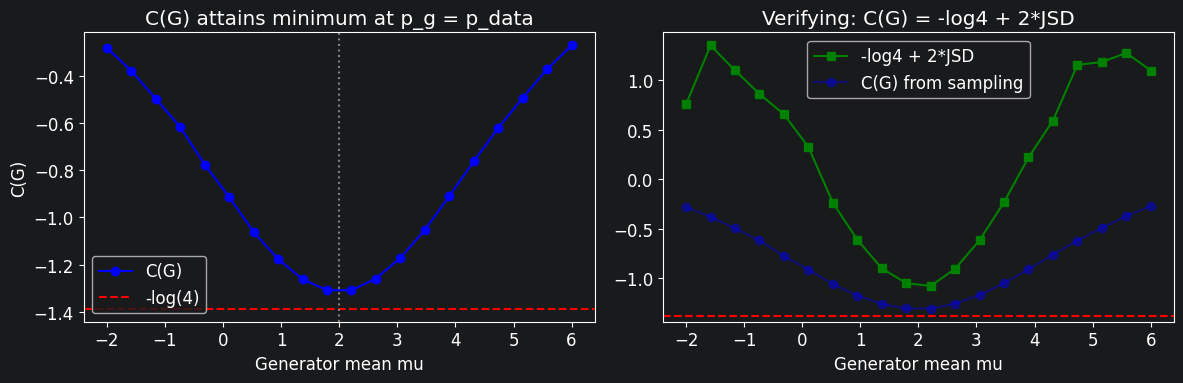

In [7]:
def kl_divergence(p_samples, q_samples, bins=200):
    """Estimate KL(P||Q) from samples via histogram discretisation."""
    all_samples = np.concatenate([p_samples, q_samples])
    bin_edges = np.linspace(all_samples.min() - 0.5, all_samples.max() + 0.5, bins + 1)
    p_hist, _ = np.histogram(p_samples, bins=bin_edges, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bin_edges, density=True)
    mask = (p_hist > 0) & (q_hist > 0)
    return np.sum(p_hist[mask] * np.log(p_hist[mask] / q_hist[mask])) * (bin_edges[1] - bin_edges[0])

def js_divergence(p_samples, q_samples):
    """JSD(P||Q) = 0.5*KL(P||M) + 0.5*KL(Q||M) where M is the mixture."""
    return 0.5 * kl_divergence(p_samples, q_samples) + 0.5 * kl_divergence(q_samples, p_samples)

# ---- Verify Equation (6): C(G) = -log4 + 2*JSD  for our Gaussian example ----
mu_g = 0.0
real_samples = np.random.randn(50_000) * 1.0 + 2.0
fake_samples = np.random.randn(50_000) * 1.5 + mu_g

p_g_mu = lambda x: norm.pdf(x, loc=mu_g, scale=1.5)
D_opt_mu = lambda x: p_data(x) / (p_data(x) + p_g_mu(x) + 1e-12)
c_g = np.mean(np.log(D_opt_mu(real_samples) + 1e-12)) +       np.mean(np.log(1 - D_opt_mu(fake_samples) + 1e-12))

jsd_est = js_divergence(real_samples[:5000], fake_samples[:5000])

print(f"C(G)  via sampling  = {c_g:.4f}")
print(f"-log4 + 2*JSD est   = {-np.log(4) + 2*jsd_est:.4f}")
print(f"JSD estimate        = {jsd_est:.4f}")

# ---- Sweep: show C(G) tracks JSD as we move the generator ----
mus = np.linspace(-2, 6, 20)
c_vals, jsd_vals = [], []
for mu in mus:
    fs = np.random.randn(20_000) * 1.5 + mu
    p_g_m = lambda x: norm.pdf(x, loc=mu, scale=1.5)
    D_om = lambda x: p_data(x) / (p_data(x) + p_g_m(x) + 1e-12)
    c_vals.append(np.mean(np.log(D_om(real_samples) + 1e-12)) +
                  np.mean(np.log(1 - D_om(fs) + 1e-12)))
    jsd_vals.append(js_divergence(real_samples[:3000], fs[:3000]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(mus, c_vals, 'b-o', label='C(G)')
ax1.axhline(-np.log(4), color='r', linestyle='--', label='-log(4)')
ax1.axvline(2.0, color='gray', linestyle=':')
ax1.set_xlabel('Generator mean mu'); ax1.set_ylabel('C(G)'); ax1.legend()
ax1.set_title('C(G) attains minimum at p_g = p_data')

ax2.plot(mus, -np.log(4) + 2*np.array(jsd_vals), 'g-s', label='-log4 + 2*JSD')
ax2.plot(mus, c_vals, 'b-o', alpha=0.4, label='C(G) from sampling')
ax2.axhline(-np.log(4), color='r', linestyle='--')
ax2.set_xlabel('Generator mean mu'); ax2.legend()
ax2.set_title('Verifying: C(G) = -log4 + 2*JSD')
plt.tight_layout(); plt.show()

---
## 6. The Non-Saturating Trick (Section 3, after Eq. 1)

The paper notes that early in training, when G is poor, log(1 - D(G(z))) **saturates**
(its gradient goes to 0), giving G no useful signal.

**Instead** of minimising log(1 - D(G(z))), they **maximise log D(G(z))**:

$$
\text{Original G loss: } \nabla_{\theta_g} \frac{1}{m}\sum \log(1 - D(G(z^{(i)})))  \qquad \text{(saturates)}
$$

$$
\text{Practical G loss: } \nabla_{\theta_g} \frac{1}{m}\sum -\log D(G(z^{(i)}))  \qquad \text{(strong gradients)}
$$

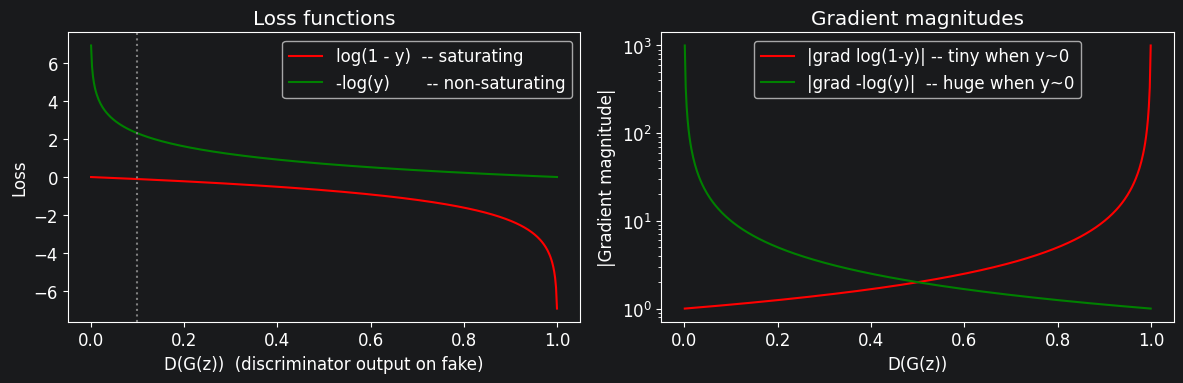

When D(G(z)) ~ 0 (G is bad, D is confident):
  log(1-y) gradient = -1.01  (small -> G learns slowly)
  -log(y)  gradient = -100.00   (large -> G learns fast)


In [8]:
# ---- Visualise the saturation problem ----
y = np.linspace(0.001, 0.999, 500)   # y = D(G(z))

loss_saturating  = np.log(1 - y)      # original: minimise this  -> gradient small when y~0
loss_nonsaturating = -np.log(y)       # practical: minimise this -> large gradient when y~0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(y, loss_saturating, 'r-', label='log(1 - y)  -- saturating')
ax1.plot(y, loss_nonsaturating, 'g-', label='-log(y)       -- non-saturating')
ax1.set_xlabel('D(G(z))  (discriminator output on fake)'); ax1.set_ylabel('Loss')
ax1.set_title('Loss functions'); ax1.legend()
ax1.axvline(0.1, color='gray', linestyle=':')

# Gradients
grad_sat  = -1 / (1 - y)   # d/dy log(1-y)
grad_nsat = -1 / y          # d/dy -log(y)
ax2.plot(y, np.abs(grad_sat), 'r-', label='|grad log(1-y)| -- tiny when y~0')
ax2.plot(y, np.abs(grad_nsat), 'g-', label='|grad -log(y)|  -- huge when y~0')
ax2.set_xlabel('D(G(z))'); ax2.set_ylabel('|Gradient magnitude|')
ax2.set_title('Gradient magnitudes'); ax2.legend()
ax2.set_yscale('log')
plt.tight_layout(); plt.show()

print("When D(G(z)) ~ 0 (G is bad, D is confident):")
print(f"  log(1-y) gradient = {-1/(1-0.01):.2f}  (small -> G learns slowly)")
print(f"  -log(y)  gradient = {-1/0.01:.2f}   (large -> G learns fast)")

---
## 7. Mini GAN on a 1D Toy Problem

Here we train a tiny GAN from scratch to see Equations (1)-(6) in action.
The data is a mixture of two Gaussians; the generator learns to match it.

Training tiny 1D GAN...


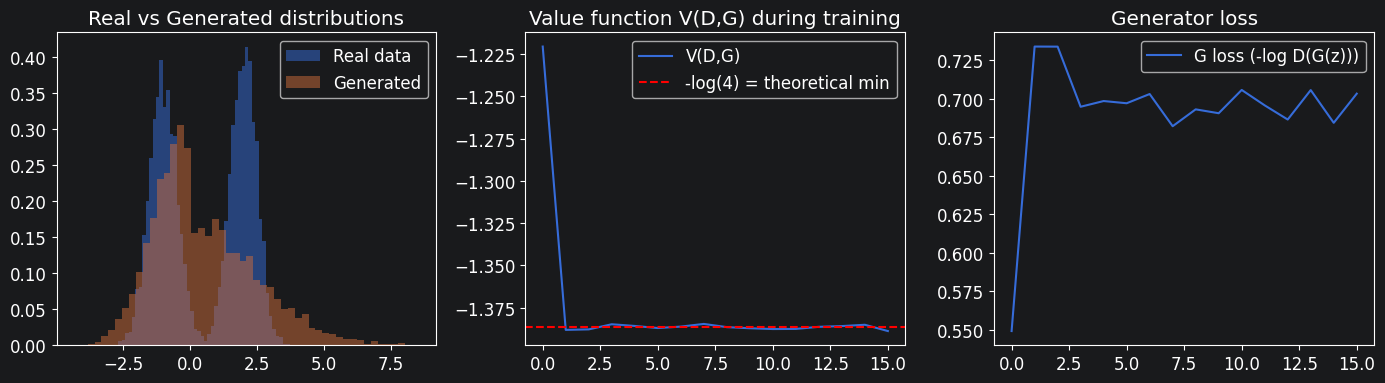

Final V(D,G)     = -1.3888
Theoretical min  = -1.3863
Real mean = 0.54, Fake mean = 0.48
Real std  = 1.58, Fake std  = 1.87


In [9]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def sample_real(batch_size):
    """p_data = 0.5*N(-1, 0.5) + 0.5*N(2, 0.5)"""
    component = np.random.rand(batch_size) < 0.5
    samples = np.where(component,
                       np.random.randn(batch_size) * 0.5 - 1.0,
                       np.random.randn(batch_size) * 0.5 + 2.0)
    return samples.reshape(-1, 1).astype(np.float32)

def train_minigan_numpy(steps=8000, batch_size=128, hdim=32, lr=0.002, k_d=1):
    """Train a 1D GAN with explicit backprop in numpy."""
    # ---- Generator params ----
    G_W1 = np.random.randn(1, hdim) * np.sqrt(2.0 / 1)
    G_b1 = np.zeros(hdim)
    G_W2 = np.random.randn(hdim, 1) * np.sqrt(2.0 / hdim)
    G_b2 = np.zeros(1)
    
    # ---- Discriminator params ----
    D_W1 = np.random.randn(1, hdim) * np.sqrt(2.0 / 1)
    D_b1 = np.zeros(hdim)
    D_W2 = np.random.randn(hdim, 1) * np.sqrt(2.0 / hdim)
    D_b2 = np.zeros(1)
    
    history = {'v': [], 'g_loss': [], 'd_loss': []}
    
    for step in range(steps):
        real = sample_real(batch_size)
        
        # ---- Train D for k_d steps ----
        for _ in range(k_d):
            z = np.random.randn(batch_size, 1)
            # G forward
            G_h = np.maximum(0, z @ G_W1 + G_b1)
            fake = G_h @ G_W2 + G_b2
            
            # D forward (real)
            D_h_real = np.maximum(0, real @ D_W1 + D_b1)
            D_out_real = sigmoid(D_h_real @ D_W2 + D_b2)
            # D forward (fake)
            D_h_fake = np.maximum(0, fake @ D_W1 + D_b1)
            D_out_fake = sigmoid(D_h_fake @ D_W2 + D_b2)
            
            # D loss: -mean[log D(real)] - mean[log(1 - D(fake))]  (minimise neg V)
            d_loss = -(np.mean(np.log(D_out_real + 1e-8)) + np.mean(np.log(1 - D_out_fake + 1e-8)))
            
            # D backward (manual backprop)
            dL_dDreal = -1.0 / (D_out_real + 1e-8) / batch_size
            dL_dDfake =  1.0 / (1 - D_out_fake + 1e-8) / batch_size
            
            # Grad through sigmoid: dsig = sig * (1 - sig)
            dDreal = dL_dDreal * D_out_real * (1 - D_out_real)
            dDfake = dL_dDfake * D_out_fake * (1 - D_out_fake)
            
            # Grad to D_W2, D_b2
            dD_W2 = D_h_real.T @ dDreal + D_h_fake.T @ dDfake
            dD_b2 = np.sum(dDreal, axis=0) + np.sum(dDfake, axis=0)
            
            # Grad through ReLU to D_W1, D_b1
            dD_hreal = (dDreal @ D_W2.T) * (D_h_real > 0)
            dD_hfake = (dDfake @ D_W2.T) * (D_h_fake > 0)
            dD_W1 = real.T @ dD_hreal + fake.T @ dD_hfake
            dD_b1 = np.sum(dD_hreal, axis=0) + np.sum(dD_hfake, axis=0)
            
            # Update D (gradient ASCENT on V = gradient DESCENT on -V)
            D_W2 -= lr * dD_W2; D_b2 -= lr * dD_b2
            D_W1 -= lr * dD_W1; D_b1 -= lr * dD_b1
        
        # ---- Train G (non-saturating: minimise -log D(G(z))) ----
        z = np.random.randn(batch_size, 1)
        G_h = np.maximum(0, z @ G_W1 + G_b1)
        fake = G_h @ G_W2 + G_b2
        D_h_fake = np.maximum(0, fake @ D_W1 + D_b1)
        D_out_fake = sigmoid(D_h_fake @ D_W2 + D_b2)
        
        # G loss: -mean[log D(G(z))]
        g_loss = -np.mean(np.log(D_out_fake + 1e-8))
        
        # Backward through D and G
        dL_dG = -1.0 / (D_out_fake + 1e-8) / batch_size
        dG = dL_dG * D_out_fake * (1 - D_out_fake)
        
        # Through D layers back to fake
        d_fake_D = (dG @ D_W2.T) * (D_h_fake > 0)
        d_fake = d_fake_D @ D_W1.T
        
        # Through G layers
        dG_W2 = G_h.T @ d_fake
        dG_b2 = np.sum(d_fake, axis=0)
        dG_h = (d_fake @ G_W2.T) * (G_h > 0)
        dG_W1 = z.T @ dG_h
        dG_b1 = np.sum(dG_h, axis=0)
        
        # Update G
        G_W2 -= lr * dG_W2; G_b2 -= lr * dG_b2
        G_W1 -= lr * dG_W1; G_b1 -= lr * dG_b1
        
        # ---- Logging ----
        if step % 500 == 0:
            history['v'].append(-d_loss)   # V = -d_loss
            history['g_loss'].append(g_loss)
            history['d_loss'].append(d_loss)
    
    # Return the trained generator function
    def G_trained(z_in):
        h = np.maximum(0, z_in @ G_W1 + G_b1)
        return h @ G_W2 + G_b2
    
    return G_trained, history

# ---- Train ----
print("Training tiny 1D GAN...")
G_trained, hist = train_minigan_numpy(steps=8000, batch_size=128, hdim=32, lr=0.002)

# ---- Plot results ----
z_test = np.random.randn(5000, 1)
fake_samples = G_trained(z_test).flatten()
real_test = sample_real(5000).flatten()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Generated vs real distribution
axes[0].hist(real_test, bins=50, alpha=0.5, density=True, label='Real data')
axes[0].hist(fake_samples, bins=50, alpha=0.5, density=True, label='Generated')
axes[0].set_title('Real vs Generated distributions')
axes[0].legend()

# Training curves
axes[1].plot(hist['v'], label='V(D,G)')
axes[1].axhline(-np.log(4), color='r', linestyle='--', label='-log(4) = theoretical min')
axes[1].set_title('Value function V(D,G) during training')
axes[1].legend()

axes[2].plot(hist['g_loss'], label='G loss (-log D(G(z)))')
axes[2].set_title('Generator loss')
axes[2].legend()

plt.tight_layout(); plt.show()

print(f"Final V(D,G)     = {hist['v'][-1]:.4f}")
print(f"Theoretical min  = {-np.log(4):.4f}")
print(f"Real mean = {real_test.mean():.2f}, Fake mean = {fake_samples.mean():.2f}")
print(f"Real std  = {real_test.std():.2f}, Fake std  = {fake_samples.std():.2f}")

---
## 8. Equation Summary

| Eq | Formula | Role |
|---|---|---|
| (1) | min_G max_D V = E_pdata[log D] + E_pz[log(1-D(G(z)))] | **Game definition** |
| (2) | D*_G = p_data / (p_data + p_g) | **Optimal discriminator** |
| (3) | V = integral [p_data log D + p_g log(1-D)] dx | **Integral form (for proof)** |
| (4) | C(G) = max_D V(G,D) = E[log D*] + E[log(1-D*)] | **Generator's cost when D is optimal** |
| (5) | C(G) = -log4 + KL(p_data || M) + KL(p_g || M) | **Connection to KL divergence** |
| (6) | C(G) = -log4 + 2*JSD(p_data || p_g) | **GANs minimise Jensen-Shannon divergence** |
| Alg 1 | grad_theta_d (1/m) sum [log D(x) + log(1-D(G(z)))] | **Stochastic gradient ascent (D)** |
| Alg 1 | grad_theta_g (1/m) sum log(1-D(G(z)))  (or -log D(G(z))) | **Stochastic gradient descent (G)** |

## References

- Goodfellow et al. (2014): https://proceedings.neurips.cc/paper_files/paper/2014/file/f033ed80deb0234979a61f95710dbe25-Paper.pdf
- Original code: https://github.com/goodfeli/adversarial